In [ ]:
# Данный ноутбук нужен только для того, чтобы посмотреть как применяются аугментации (эррозию и дилатацию в итоге убрал)

In [19]:
from mnist_synthetic.torch.datasets.CyrillicEMNISTSynthetic import CyrillicEMNISTSynthetic

In [20]:
import importlib

import torch
from torchvision import transforms
import torchvision.transforms as T
from torchvision.transforms import functional as F

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

# Перезагрузка модуля. Надо перезагружать эту ячейку, если что-то поменяли в генераторе
importlib.reload(importlib.import_module('mnist_synthetic.lower_case_letters_generator'))
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

generator = LowerCaseLettersGenerator(seed=42)

transform_nearest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),
])

transform_bilinear = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BILINEAR),
])

transform_bicubic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BICUBIC),
])

In [21]:
dataset = CyrillicEMNISTSynthetic(
    size=5000,
    seed=42,
    include=['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж'],  # Только указанные символы
    transform=transforms.ToTensor()
)

#dataset = CyrillicEMNISTSynthetic( # Все символы в датасете
#    size=10000,
#    seed=42,
#   transform=transforms.ToTensor()
#)

img, label = dataset[0]
print(f"Label: {label}")

Label: а


In [22]:
# Кастомные трансформы

class RandomErodeDilate:
    """Случайная эрозия или дилатация изображения."""

    def __init__(self, kernel_size: int = 3, apply_erode: bool = True,
                 apply_dilate: bool = True, p: float = 0.5):
        self.kernel_size = kernel_size
        self.apply_erode = apply_erode
        self.apply_dilate = apply_dilate
        self.p = p
        self.kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    def __call__(self, img):
        if torch.rand(1) > self.p:
            return img

        # Конвертируем тензор в numpy array
        if isinstance(img, torch.Tensor):
            img_np = img.squeeze(0).numpy() * 255  # (1, H, W) -> (H, W)
            img_np = img_np.astype(np.uint8)
        else:
            img_np = np.array(img)

        # Применяем эрозию или дилатацию
        if self.apply_erode and self.apply_dilate:
            if torch.rand(1) > 0.5:
                img_np = cv2.erode(img_np, self.kernel, iterations=1)
            else:
                img_np = cv2.dilate(img_np, self.kernel, iterations=1)
        elif self.apply_erode:
            img_np = cv2.erode(img_np, self.kernel, iterations=1)
        elif self.apply_dilate:
            img_np = cv2.dilate(img_np, self.kernel, iterations=1)

        # Конвертируем обратно в тензор
        img_np = img_np.astype(np.float32) / 255.0
        return torch.from_numpy(img_np).unsqueeze(0)


In [23]:
# Аугментации

# 1. Только эрозия
transform_erode = transforms.Compose([
    transforms.ToTensor(),
    RandomErodeDilate(kernel_size=3, apply_erode=True, apply_dilate=False, p=1.0),
])

# 2. Только дилатация
transform_dilate = transforms.Compose([
    transforms.ToTensor(),
    RandomErodeDilate(kernel_size=3, apply_erode=False, apply_dilate=True, p=1.0),
])

# 3. Случайная эрозия/дилатация
transform_morph_random = transforms.Compose([
    transforms.ToTensor(),
    RandomErodeDilate(kernel_size=3, apply_erode=True, apply_dilate=True, p=0.7),
])

# 4. RandomPerspective
transform_perspective = transforms.Compose([
    transforms.ToTensor(),
    T.RandomPerspective(distortion_scale=0.5, p=1.0),  # p=1.0 для демонстрации
])

# 5. Комбинированная: морфология + perspective
transform_combined = transforms.Compose([
    transforms.ToTensor(),
    RandomErodeDilate(kernel_size=3, apply_erode=True, apply_dilate=True, p=0.5),
    T.RandomPerspective(distortion_scale=0.5, p=0.7),
])

# 6. Базовый трансформ (без аугментаций)
transform_base = transforms.Compose([
    transforms.ToTensor(),
])


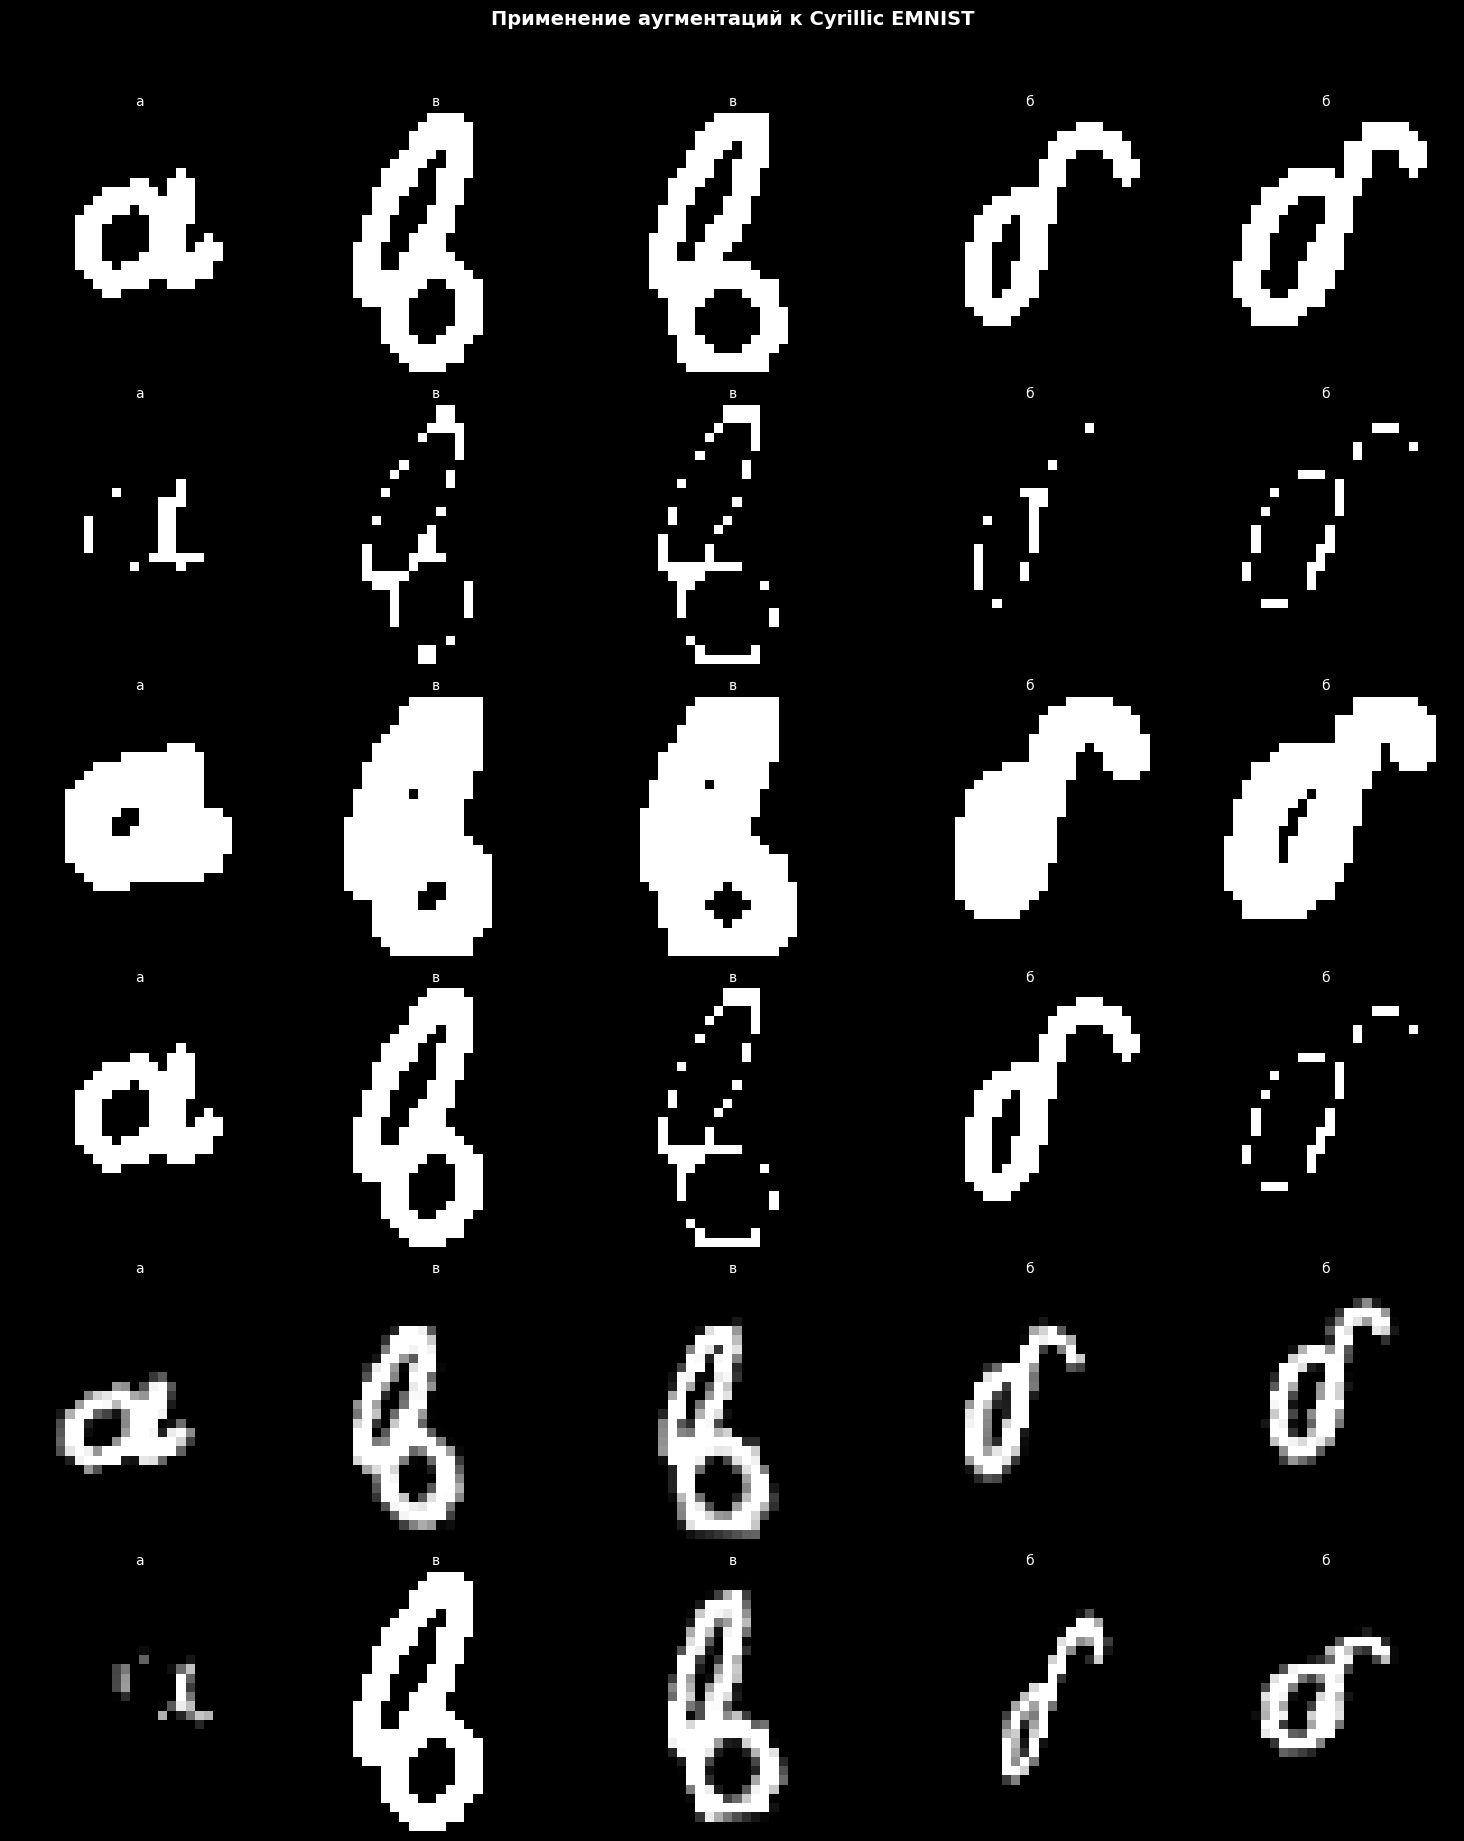

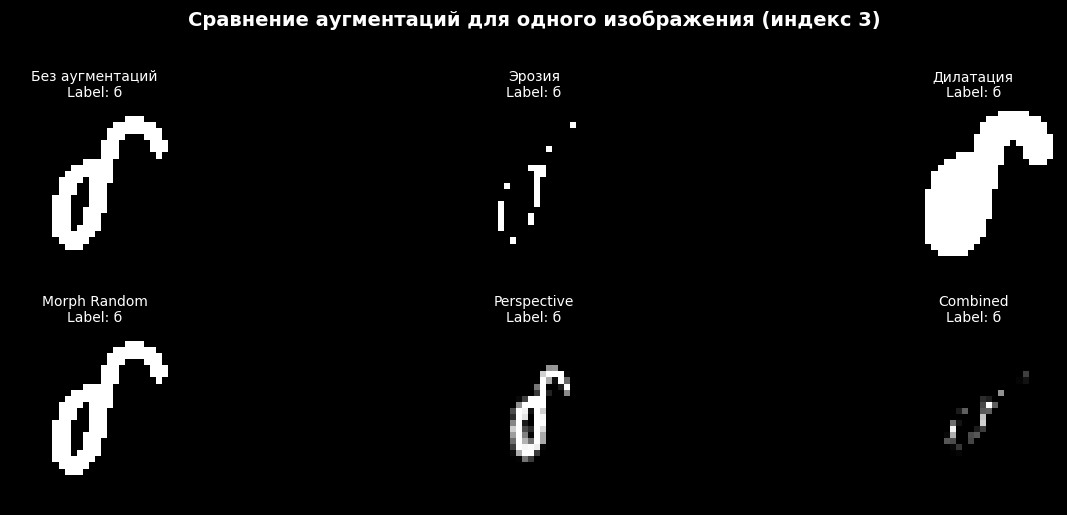

In [24]:
# Создание датасета с разными аугментациями

# Создаем датасеты с разными аугментациями
datasets_aug = {
    'Без аугментаций': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                                transform=transform_base),
    'Эрозия': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                       transform=transform_erode),
    'Дилатация': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                          transform=transform_dilate),
    'Morph Random': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                             transform=transform_morph_random),
    'Perspective': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                            transform=transform_perspective),
    'Combined': CyrillicEMNISTSynthetic(size=10, seed=42, include=['а', 'б', 'в'],
                                         transform=transform_combined),
}


# Визуализация

def plot_augmented_images(datasets: dict, num_samples: int = 5):
    """
    Визуализирует применение различных аугментаций.

    Args:
        datasets: Словарь {название: датасет}
        num_samples: Количество примеров для показа
    """
    fig, axes = plt.subplots(len(datasets), num_samples, figsize=(15, 3 * len(datasets)))

    # Если только одна строка
    if len(datasets) == 1:
        axes = axes.reshape(1, -1)

    for idx, (name, dataset) in enumerate(datasets.items()):
        for j in range(num_samples):
            img, label = dataset[j]

            ax = axes[idx, j]

            # Конвертируем тензор в numpy для отображения
            if isinstance(img, torch.Tensor):
                img_np = img.squeeze(0).numpy()
            else:
                img_np = np.array(img)

            ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'{label}', fontsize=10, pad=5)
            ax.axis('off')

        # Подпись строки
        axes[idx, 0].set_ylabel(name, fontsize=11, fontweight='bold')

    plt.suptitle('Применение аугментаций к Cyrillic EMNIST', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_single_augmentation_comparison(idx: int = 0):
    """
    Сравнивает одно и то же изображение с разными аугментациями.

    Args:
        idx: Индекс изображения в датасете
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 5))
    axes = axes.flatten()

    titles = list(datasets_aug.keys())

    for i, (name, dataset) in enumerate(datasets_aug.items()):
        img, label = dataset[idx]

        if isinstance(img, torch.Tensor):
            img_np = img.squeeze(0).numpy()
        else:
            img_np = np.array(img)

        axes[i].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f'{name}\nLabel: {label}', fontsize=10, pad=10)
        axes[i].axis('off')

    plt.suptitle(f'Сравнение аугментаций для одного изображения (индекс {idx})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Визуализация всех аугментаций
plot_augmented_images(datasets_aug, num_samples=5)

# Визуализация сравнения для конкретного примера
plot_single_augmentation_comparison(idx=3)